In [2]:
import os

###############################################################################
# Decide on CPU or GPU here
use_gpu = False  # Set to False if you want CPU only
###############################################################################

if use_gpu:
    # Prevent JAX from preallocating most of the GPU memory
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
    # Force JAX to use GPU
    import jax
    jax.config.update("jax_platform_name", "gpu")
else:
    # Force JAX to use CPU
    import jax
    jax.config.update("jax_platform_name", "cpu")

In [3]:
import numpy as np
from jax import jit, vjp, vmap, value_and_grad, random
import jax
from jax import numpy as jnp
from jax import lax
from jaxdf.operators import compose
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, clear_output

# from cmcrameri import cm

import optax
import equinox as eqx
from jax.example_libraries import optimizers
import time


from jwave.geometry import Domain, Medium
from jwave.signal_processing import smooth

key = random.PRNGKey(42)  # Random seed


from hybridoed.forward import create_src_field, generate_2D_gridded_src_rec_positions, ricker_wavelet, acoustic2D, acoustic2D_pml,acoustic2D_pml_minmem, acoustic2D_pml_4th_minmem, generate_src_rec_positions, acoustic2D_cpml_minmem, cfl_dt, solve_phi_wave_2d

from hybridoed.oed import *


In [4]:


# ---- physical domain (meters) ----
Lx, Ly = 0.6, 0.6               # FIXED domain size
c_min = 1500.0            # air (m/s)
c_max = 5750.0            # plexiglass (m/s)

# ---- resolution chosen ONCE for the highest test frequency ----
f0_max = 25e3                     # highest center freq you'll run
fmax   = 2.0 * f0_max             # Ricker top-end
PPW    = 10                       # for 2nd-order space; 10–12 is typical

dx_req = c_min / (PPW * fmax)
dx = dy = dx_req                  # keep this fixed for all runs

# grid size from physical size
nx = int(np.floor(Lx / dx)) + 1
ny = int(np.floor(Ly / dy)) + 1
dx = Lx / (nx - 1)                # snap dx to fit exactly
dy = Ly / (ny - 1)

print(f"nx, ny = {nx}, {ny}  |  dx = {dx*1e3:.2f} mm, dy = {dy*1e3:.2f} mm")

# ---- stable time step (keep FIXED) ----
dt_max = min(dx,dy) / (c_max * np.sqrt(2.0))   # 2-D CFL for staggered first-order
dt = 0.8 * dt_max                              # margin
print(f"dt = {dt*1e6:.2f} µs")

# ---- PML thickness in METERS (fixed), converted to cells ----
pml_thickness_m = 0.1                         # e.g., 3 cm per side
pml_width = max(4, int(round(pml_thickness_m / dx)))
print(f"pml_width = {pml_width} cells (~{pml_width*dx*100:.1f} cm)")

# ---- material model (fixed in meters) ----
velocity = c_min
density  = 1180.0

true_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)
homo_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)
# scatterer defined in METERS, then mapped to indices
# scx0, scx1 = 0.3+0.15+0.05-0.0172, 0.3+0.15+0.05+0.0172    
# scy0, scy1 = 0.3+0.15-0.05-0.0172, 0.3+0.15-0.05+0.0172    
scx0, scx1 = 0.15 +0.15+0.05-0.035/2, 0.15+0.15+0.05+0.035/2 
scy0, scy1 = 0.15+0.15-0.05-0.035/2, 0.15+0.15-0.05+0.035/2
ix0, ix1 = int(scx0/dx), int(scx1/dx)
iy0, iy1 = int(scy0/dy), int(scy1/dy)
true_model = true_model.at[ix0:ix1, iy0:iy1].set(c_max)

density_grid = jnp.full_like(true_model, density)

# ---- geometry in METERS (then to index floats) ----
# One source 2 cm from left wall, centered vertically
# src_x_m, src_y_m = 0.3,0.3
# define a 2D grid of sources        
src_x_m_list = np.linspace(0.15, 0.45, 3)
src_y_m_list = np.linspace(0.15, 0.45, 3)
src_indices = []
for x in src_x_m_list:
    for y in src_y_m_list:
        src_indices.append([x / dx, y / dy])

src_indices = jnp.array(src_indices, dtype=jnp.float32)

# 2D grid of receivers: 
n_rx, n_ry = 30,30
rec_x_m = np.linspace(0.15, 0.45, n_rx)
rec_y_m = np.linspace(0.15, 0.45, n_ry)
rec_xx, rec_yy = np.meshgrid(rec_x_m, rec_y_m, indexing='ij')
receiver_is = jnp.stack([rec_xx.ravel() / dx, rec_yy.ravel() / dy], axis=1).astype(jnp.float32)

# ---- time window FIXED in seconds ----
T = 500e-6                     # e.g., 120 µs fixed
n_steps = int(np.ceil(T / dt))
print(f"n_steps = {n_steps}, total time = {n_steps*dt*1e6:.1f} µs")

# ---- run for any f0 (ONLY f0 changes) ----
f0 = 25e3  # try 10e3, 25e3, 40e3 without changing grid/dt
ys = acoustic2D_cpml_minmem(
    true_model, density_grid, src_indices[2], f0,
    dx, dy, dt, n_steps,
    receiver_is=receiver_is,
    output_wavefield=True,
    pml_width=pml_width,
    R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
)
seis = ys[0]  # (n_steps, Nrec)
wavefields_test = ys[1]  # (n_steps, nx, ny)

ys_homo = acoustic2D_cpml_minmem(
    homo_model, density_grid, src_indices[2], f0,
    dx, dy, dt, n_steps,
    receiver_is=receiver_is,
    output_wavefield=True,
    pml_width=pml_width,
    R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
)
seis_homo = ys_homo[0]  # (n_steps, Nrec)



# print("------Now running with solve_phi_wave_2d------")
# # dt = cfl_dt(true_model, (dx, dy), cfl=0.40)
# print(f"Chosen time step: {dt:.2e} seconds")
# n_steps = int(np.ceil(T / dt))
# print(f"Number of time steps: {n_steps} for total time {n_steps*dt:.2e} seconds")

# # arbitrary wavelet array (you can pass literally anything)
time = jnp.arange(n_steps) * dt
# my_wavelet_array = ricker_wavelet(time, f0, 5.8*10e-6)  # (nt,)
# plt.plot(time*1e6, my_wavelet_array)
# wavelet = jnp.asarray(my_wavelet_array*10e9, dtype=jnp.float32)  # (nt,)



# out = solve_phi_wave_2d(
#     c=true_model,                 # (nx, ny) velocity model [m/s]
#     rho=density_grid,                 # or None
#     spacing=(dx, dy),
#     dt=dt,
#     source_xy=src_indices[0],  
#     source_wavelet=wavelet,
#     receiver_xy=receiver_is,  
# )


nx, ny = 201, 201  |  dx = 3.00 mm, dy = 3.00 mm
dt = 0.30 µs
pml_width = 33 cells (~9.9 cm)
n_steps = 1695, total time = 500.3 µs


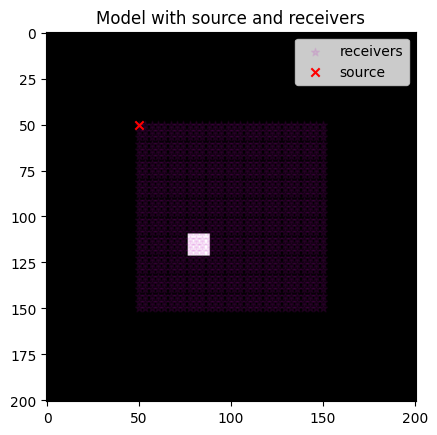

In [5]:
plt.scatter(receiver_is[:,1], receiver_is[:,0], c="m", marker="*", label="receivers", alpha=0.1)
plt.scatter(src_indices[0][1], src_indices[0][0], c="r", marker="x", label="source")
plt.imshow(true_model, cmap='grey')
plt.legend()
plt.title("Model with source and receivers")
plt.show()

In [6]:
# make a shot gather with the x axis being the y position
# sorte the trace by y position
source_x, source_y = src_indices[0][0], src_indices[0][1]
receiver_x, receiver_y = receiver_is[:,0], receiver_is[:,1]
sorted_indices_y = np.argsort(receiver_y)
sorted_offsets_y = receiver_y[sorted_indices_y]
sorted_traces_y = seis[:, sorted_indices_y]
n_traces_y = sorted_traces_y.shape[1]
n_samples_y = sorted_traces_y.shape[0]

# sorted_traces_y_solve = out["phi_rec"][:, sorted_indices_y]

# extract a receiver line at a fixed x position (e.g., the middle of the domain)
fixed_x = Lx / 2
# find the receiver closest to this x position
closest_idx = np.argmin(np.abs(receiver_x - fixed_x))
fixed_x_trace = seis[:, closest_idx]


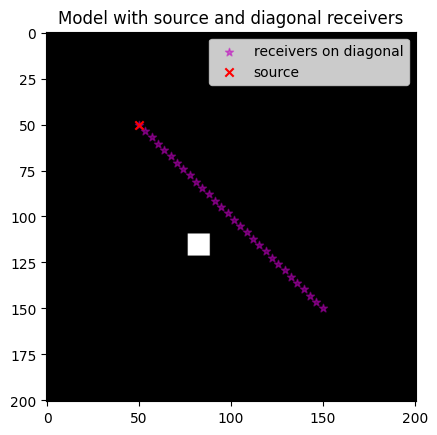

In [7]:
# plot only the receivers on the diagonal
receiver_is_diag = receiver_is[receiver_is[:,0] == receiver_is[:,1]]
plt.scatter(receiver_is_diag[:,1], receiver_is_diag[:,0], c="m", marker="*", label="receivers on diagonal", alpha=0.5)
plt.scatter(source_x, source_y, c="r", marker="x", label="source")
plt.imshow(true_model,cmap='grey')
plt.legend()
plt.title("Model with source and diagonal receivers")
plt.show()

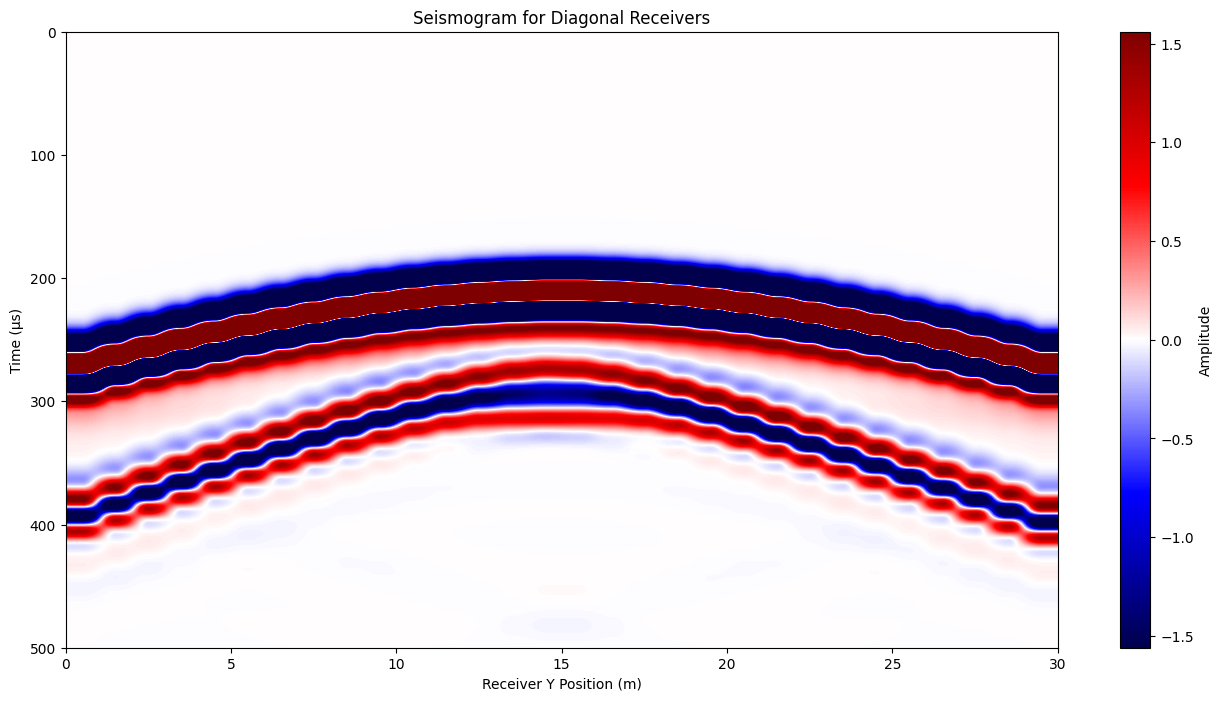

In [8]:
# plot only the traces from the diagonal receivers as an image
plt.figure(figsize=(16,8))
receiver_is_diag = receiver_is[receiver_is[:,0] == receiver_is[:,1]]
diag_indices = np.where((receiver_is[:,0] == receiver_is[:,1]))[0]
# diag_traces = out["phi_rec"][:, diag_indices]
diag_traces = seis[:, diag_indices]
# plt.imshow(diag_traces, aspect='auto', extent=[ receiver_is[diag_indices,1].min() * dx, receiver_is[diag_indices,1].max() * dx,time[-1]*1e6,0],cmap='seismic', vmin=-np.max(np.abs(diag_traces))/10, vmax=np.max(np.abs(diag_traces))/10)
plt.imshow(diag_traces, aspect='auto', extent=[0,30, T*1e6,0],cmap='seismic', vmin=-np.max(np.abs(diag_traces))/10, vmax=np.max(np.abs(diag_traces))/10)
plt.colorbar(label='Amplitude')
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.title('Seismogram for Diagonal Receivers')
plt.show()

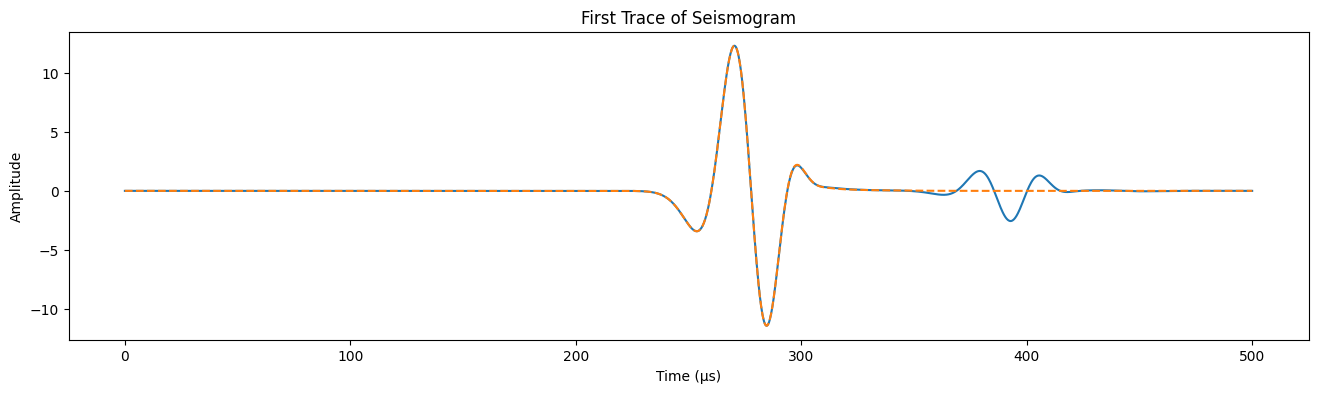

In [9]:
# plot only the firts trace
# plt.plot(time*1e6, out["phi_rec"][:, 0])
plt.figure(figsize=(16,4))
plt.plot(time*1e6, seis[:, 0], label="Original")
plt.plot(time*1e6, seis_homo[:, 0], label="Homogeneous", linestyle='--')
# plt.plot(time*1e6, out["phi_rec"][:, 0])
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.title('First Trace of Seismogram')
plt.show()

In [10]:
def apply_dispersion_phase_shift(
    traces: np.ndarray,
    dt: float,
    dist: np.ndarray,
    cp_of_f,
    c_ref: float,
    fmin: float | None = None,
    fmax: float | None = None,
    phase_only: bool = True,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Apply an 'engineering' dispersive correction by phase-shifting in frequency domain.

    Parameters
    ----------
    traces : (n_traces, n_samples) array
        Time series at each receiver.
    dt : float
        Sampling interval [s].
    dist : (n_traces,) array
        Source-to-receiver distance for each trace [m].
    cp_of_f : callable or (f, cp) tuple
        If callable: cp_of_f(f_hz) -> phase velocity [m/s] for array f_hz.
        If tuple: (f_hz_array, cp_array) used with linear interpolation.
    c_ref : float
        Reference (nondispersive) velocity used in your acoustic simulation [m/s].
    fmin, fmax : float or None
        Optional band-limits [Hz] where dispersion is applied.
        Outside the band, no phase correction is applied.
    phase_only : bool
        If True, keep amplitude unchanged (recommended). If False, you can extend this
        later to include attenuation (not implemented here).
    eps : float
        Small number to avoid division by zero.

    Returns
    -------
    disp_traces : (n_traces, n_samples) array
        Dispersed traces.
    """
    traces = np.asarray(traces, dtype=float)
    dist = np.asarray(dist, dtype=float)

    if traces.ndim != 2:
        raise ValueError("traces must be 2D (n_traces, n_samples)")
    n_tr, nt = traces.shape
    if dist.shape != (n_tr,):
        raise ValueError(f"dist must have shape (n_traces,), got {dist.shape}")

    # Build cp(f) accessor
    if isinstance(cp_of_f, tuple) or isinstance(cp_of_f, list):
        f_tab = np.asarray(cp_of_f[0], dtype=float)
        cp_tab = np.asarray(cp_of_f[1], dtype=float)
        if f_tab.ndim != 1 or cp_tab.ndim != 1 or f_tab.size != cp_tab.size:
            raise ValueError("cp_of_f as tuple must be (f_array, cp_array) with same length")

        def _cp(f_hz: np.ndarray) -> np.ndarray:
            # clip to tabulated bounds to avoid extrapolation surprises
            f_clipped = np.clip(f_hz, f_tab.min(), f_tab.max())
            return np.interp(f_clipped, f_tab, cp_tab)
    elif callable(cp_of_f):
        _cp = cp_of_f
    else:
        raise ValueError("cp_of_f must be a callable or a (f_array, cp_array) tuple")

    # Frequency axis for rFFT
    f = np.fft.rfftfreq(nt, d=dt)  # (n_freq,)
    omega = 2.0 * np.pi * f

    # Compute cp(f)
    cp = np.asarray(_cp(f), dtype=float)
    cp = np.maximum(cp, eps)

    # Compute delta slowness and delta tau per trace
    delta_s = (1.0 / cp) - (1.0 / max(c_ref, eps))  # (n_freq,)
    # (n_traces, n_freq) via outer product
    delta_tau = dist[:, None] * delta_s[None, :]  # seconds

    # Optional band-limit where to apply correction
    if fmin is not None or fmax is not None:
        mask = np.ones_like(f, dtype=bool)
        if fmin is not None:
            mask &= (f >= fmin)
        if fmax is not None:
            mask &= (f <= fmax)
        # outside band: delta_tau = 0 -> no phase change
        delta_tau = np.where(mask[None, :], delta_tau, 0.0)

    # FFT traces
    U = np.fft.rfft(traces, axis=1)  # (n_traces, n_freq)

    # Apply phase shift
    phase = np.exp(-1j * omega[None, :] * delta_tau)
    U_disp = U * phase

    # Back to time
    disp_traces = np.fft.irfft(U_disp, n=nt, axis=1)

    return disp_traces


In [11]:
diag_traces.T.shape

(30, 1695)

In [12]:
import pandas as pd
# path to your exported file
file = "dispersion_curve_test_A_Lamb.txt"

# read file (it is comma-separated)
df = pd.read_csv(file)

f_A0 = df["A0 f (kHz)"].values
c_A0 = df["A0 Phase velocity (m/ms)"].values

# Remove NaNs (important: higher modes end earlier)
mask = ~np.isnan(f_A0) & ~np.isnan(c_A0)

f_A0 = f_A0[mask] * 1e3        # kHz → Hz
c_A0 = c_A0[mask] * 1e3        # m/ms → m/s

In [13]:
# traces: (nrec, nt)
# dt in seconds
# dist: (nrec,) in meters
# dist only for the diagonal receivers
dist = np.sqrt((receiver_is[diag_indices,0] - source_x)**2 + (receiver_is[diag_indices,1] - source_y)**2) * dx
# Provide cp(f) as arrays (f_hz, cp_mps)
# f_cp = np.array([...])
# cp = np.array([...])

disp = apply_dispersion_phase_shift(diag_traces.T, dt, dist, (f_A0, c_A0), c_ref=1200.0)

In [14]:
disp

array([[-3.86662187e-16, -1.29570846e-15,  2.19360133e-16, ...,
        -5.22619463e-04, -5.92245779e-04, -6.60046411e-04],
       [-2.82954677e-04, -3.39160267e-04, -4.40692890e-04, ...,
        -2.72974817e-05, -1.24659135e-04, -1.83965977e-04],
       [ 1.72262855e-03,  1.63956941e-03,  1.53177040e-03, ...,
         2.02108186e-03,  1.91435044e-03,  1.83028593e-03],
       ...,
       [ 2.25335464e-02,  3.34746205e-02,  4.43654724e-02, ...,
        -1.01561922e-02,  6.79810160e-04,  1.15904676e-02],
       [-1.31883327e+00, -1.29615242e+00, -1.27101613e+00, ...,
        -1.36813874e+00, -1.35522789e+00, -1.33865809e+00],
       [ 1.88721266e+00,  1.95470006e+00,  2.01207234e+00, ...,
         1.62713049e+00,  1.72305130e+00,  1.80988252e+00]],
      shape=(30, 1695))

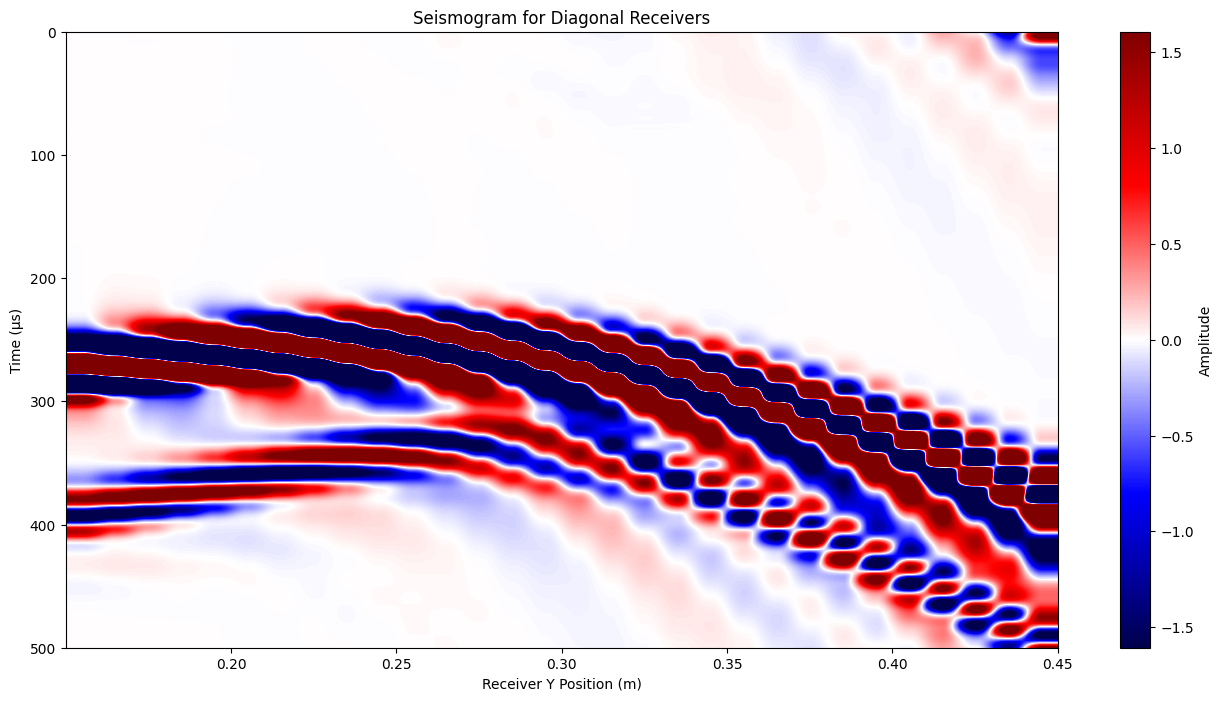

In [15]:
# plot only the traces from the diagonal receivers as an image
plt.figure(figsize=(16,8))
plt.imshow(disp.T, aspect='auto', extent=[ receiver_is[diag_indices,1].min() * dx, receiver_is[diag_indices,1].max() * dx,T*1e6,0],cmap='seismic', vmin=-np.max(np.abs(disp))/10, vmax=np.max(np.abs(disp))/10)
plt.colorbar(label='Amplitude')
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.title('Seismogram for Diagonal Receivers')
plt.show()

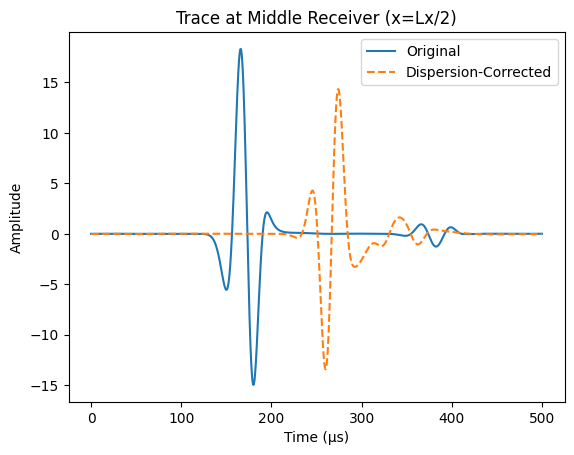

In [16]:
# plot the middle trace (closest to x=Lx/2)
# plt.plot(time*1e6, out["phi_rec"][:, 10], label="Original")
plt.plot(time*1e6, seis.T[15, :], label="Original")
plt.plot(time*1e6, disp[15,:], label="Dispersion-Corrected", linestyle='--')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.title('Trace at Middle Receiver (x=Lx/2)')
plt.legend()
plt.show()

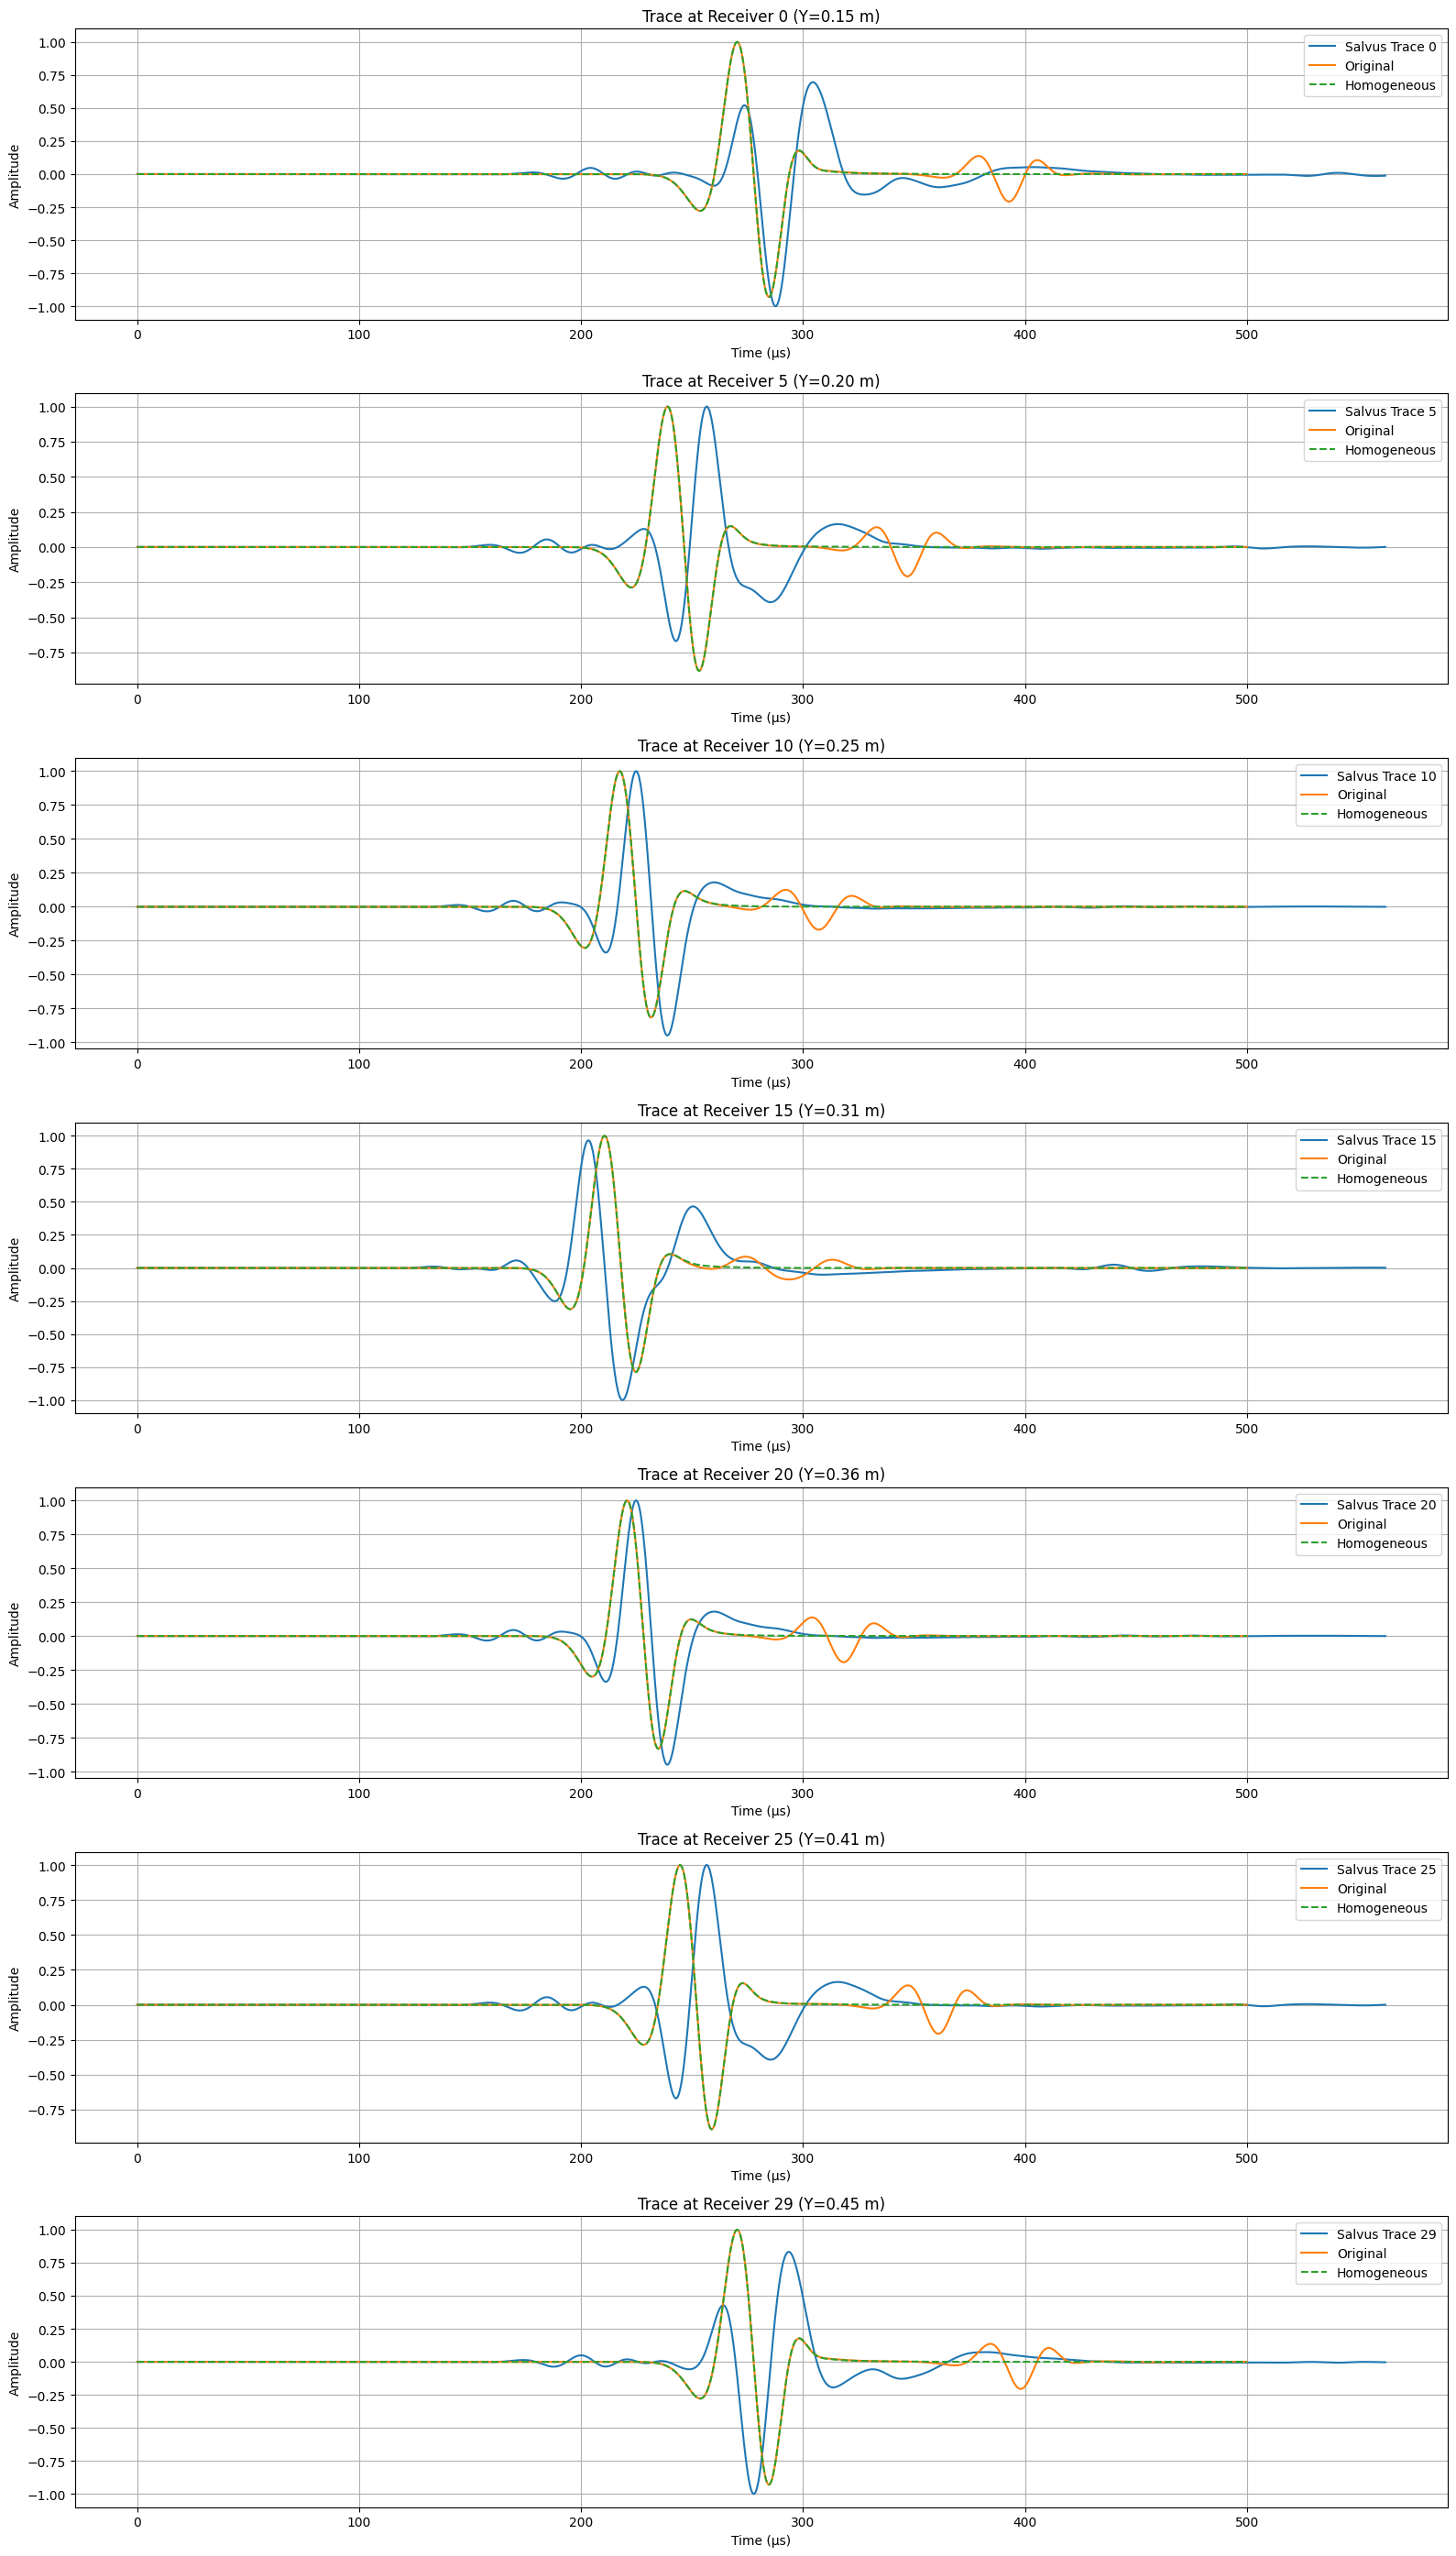

In [17]:
# read the traces from salvus
salvus_out = np.load("diagonal_traces_all.npz")  # assuming the traces are saved in a numpy file
salvus_traces = salvus_out["diagonal_traces_all"][2] # reverse the order of traces to match receiver_is order
salvus_time = salvus_out["t"]
trace_idx = [0,5,10,15,20,25,29]  # indices of traces to plot

# Create a single big figure with all traces
fig, axes = plt.subplots(len(trace_idx), 1, figsize=(16, 4*len(trace_idx)))

for i, idx in enumerate(trace_idx):
    ax = axes[i] if len(trace_idx) > 1 else axes
    ax.plot(salvus_time*1e6, salvus_traces[idx, :]/np.max(np.abs(salvus_traces[idx, :])), label=f"Salvus Trace {idx}")
    ax.plot(time*1e6, seis[:,diag_indices][:, idx]/np.max(np.abs(seis[:, diag_indices][:, idx])), label="Original")
    ax.plot(time*1e6, seis_homo[:,diag_indices][:, idx]/np.max(np.abs(seis_homo[:, diag_indices][:, idx])), label="Homogeneous", linestyle='--')
    # ax.plot(time*1e6, disp[idx,:]/np.max(np.abs(disp[idx,:])), label="Dispersion-Corrected")
    ax.grid()
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Trace at Receiver {idx} (Y={receiver_is[diag_indices[idx],1]*dx:.2f} m)')
    ax.legend()

plt.tight_layout()
# plt.savefig('diagonal_traces_comparison_dispersive.pdf', format='pdf', bbox_inches='tight')
plt.show()

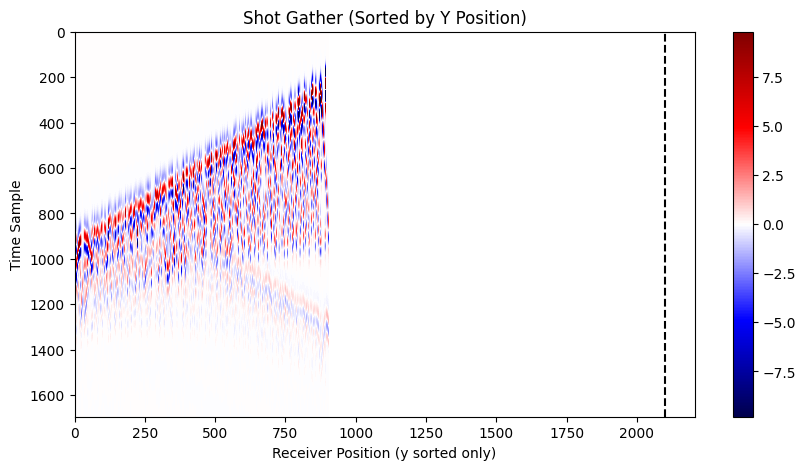

In [18]:
# plot the sorted traces as a shot gather
plt.figure(figsize=(10,5))
plt.imshow(
    jnp.flipud((sorted_traces_y)),
    aspect='auto',
    extent=[0, n_traces_y, 0, n_samples_y],
    cmap='seismic',
    vmin=-np.amax(np.abs(sorted_traces_y))/20,
    vmax=np.amax(np.abs(sorted_traces_y))/20
)
plt.axvline(2100, color='k', linestyle='--')
plt.gca().invert_yaxis()
plt.colorbar()
plt.title('Shot Gather (Sorted by Y Position)')
plt.xlabel('Receiver Position (y sorted only)')
plt.ylabel('Time Sample')
plt.show()

In [19]:
# plot the sorted traces as a shot gather
plt.figure(figsize=(10,5))
plt.imshow(
    jnp.flipud((out["p_rec"][:, sorted_indices_y])),
    aspect='auto',
    extent=[0, n_traces_y, 0, n_samples_y],
    cmap='seismic',
    vmin=-np.amax(np.abs(out["p_rec"][:, sorted_indices_y]))/20,
    vmax=np.amax(np.abs(out["p_rec"][:, sorted_indices_y]))/20
)
plt.axvline(2100, color='k', linestyle='--')
plt.gca().invert_yaxis()
plt.colorbar()
plt.title('Shot Gather (Sorted by Y Position)')
plt.xlabel('Receiver Position (y sorted only)')
plt.ylabel('Time Sample')
plt.show()

NameError: name 'out' is not defined

<Figure size 1000x500 with 0 Axes>

## Inversion setup

In [20]:
salvus_traces = salvus_out["diagonal_traces_all"]
# interpolate salvus_traces to match the time axis of our simulation if needed
# For example, if salvus_traces has a different time sampling, you can use np.interp to interpolate it to the same time points as 'time' used in our simulation.
if len(salvus_time) != len(time):
    salvus_traces_interp = np.zeros((salvus_traces.shape[0], salvus_traces.shape[1], len(time)))
    for i in range(salvus_traces.shape[0]):
        for j in range(salvus_traces.shape[1]):
            salvus_traces_interp[i, j, :] = np.interp(time, salvus_time, salvus_traces[i, j, :])
    salvus_traces = salvus_traces_interp

salvus_traces.shape, time.shape, seis[:, diag_indices].T.shape

((9, 30, 1695), (1695,), (30, 1695))

In [21]:
# mask = jnp.ones(true_model.shape, dtype=jnp.float32)

# mask = mask.at[src_indices[0], src_indices[1]].set(0.0)



def get_sound_speed(params):
    return params + compose(params)(nn.sigmoid) #* mask

# initial model is the blurred model
params = jnp.array(homo_model)
# params = homogenous_model
# params = medium.sound_speed * 0.1 + 
params

Array([[1500., 1500., 1500., ..., 1500., 1500., 1500.],
       [1500., 1500., 1500., ..., 1500., 1500., 1500.],
       [1500., 1500., 1500., ..., 1500., 1500., 1500.],
       ...,
       [1500., 1500., 1500., ..., 1500., 1500., 1500.],
       [1500., 1500., 1500., ..., 1500., 1500., 1500.],
       [1500., 1500., 1500., ..., 1500., 1500., 1500.]], dtype=float32)

In [22]:
def smooth_fun(gradient):
    # x = gradient.on_grid[..., 0]
    x = gradient
    for _ in range(1):
        x = smooth(x)
    return x
@jit
def fwi(src_position):
    # print("source position in fwi", src_position)
    num_steps_fwi = 10
    # num_steps_fwi = 150 # for pml implementation
    # num_steps_fwi = 80 # for cpml implementation
    key = random.PRNGKey(42)
    _, key = random.split(key)
    # initial model is the blurred model
    # params_fwi = blurred_model

    # def simulate_true(src):
    #     p_rec, _ = acoustic2D_pml_minmem(
    #         true_model, density, src,
    #         f0, dx, dy, dt_ben, n_steps_forward,
    #         receiver_is_modif, pml_width=pml_width, output_wavefield=True
    #     )
    #     return p_rec

    # p_data_obs = vmap(simulate_true)(src_position)  # [Nsrc, Nt, Nrec] is equivalent to making a measurements of the True model with the initial position once every start of the FWI loop

    init_fun_fwi, update_fun_fwi, get_params_fwi = optimizers.adam(25.0, 0.9, 0.9)
    opt_state_fwi = init_fun_fwi(homo_model)
    # opt_state_fwi = init_fun_fwi(homogenous_model)

    # print(f"Size of data [Source idx, Time, Sensor idx]: {p_data.shape}")

    def loss_func_fwi(opt_state_fwi, src_num):
        @jit
        def simulate_one(src_num):
            # p_rec, _ = acoustic2D_pml_minmem(
            #     opt_state_fwi, density, src_position[src_num],
            #     f0, dx, dy, dt_ben, n_steps_forward,
            #     receiver_is_modif, pml_width=pml_width, output_wavefield=True
            # )

            p_rec = acoustic2D_cpml_minmem(
                opt_state_fwi, density_grid, src_indices[src_num], f0,
                dx, dy, dt, n_steps,
                receiver_is=receiver_is,
                output_wavefield=True,
                pml_width=pml_width,
                R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
            )

            return p_rec[0][:,diag_indices].T
        
        # simulate_all = jit(vmap(simulate_one))
        # p_pred = simulate_all(src_position)
        # p_pred,_ = acoustic2D_pml_minmem(params_fwi, density, src_position[src_num], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)
        p_pred = simulate_one(src_num)

        data = jnp.array(salvus_traces)[src_num]
        print(p_pred.shape, data.shape)
        return jnp.mean((p_pred - data) ** 2)

    loss_with_grad_fwi = value_and_grad(loss_func_fwi,argnums=0)

    # Define and compile the update function
    @jit
    def update_fwi(opt_state, key, k):
        v = get_params_fwi(opt_state)
        src_num = random.choice(key, 9)
        lossval, gradient = loss_with_grad_fwi(v, src_num)
        gradient = smooth_fun(gradient)
        # gradient *= probabilities[src_num]
        return lossval, update_fun_fwi(k, gradient, opt_state)

    @jit
    def body(carry, k):
        opt_state, key = carry
        _, key = random.split(key)      # throw away first, keep second
        lossval, opt_state = update_fwi(opt_state, key, k)
        return (opt_state, key), lossval

    (opt_state_fwi, _), losses = lax.scan(body, (opt_state_fwi, key), jnp.arange(num_steps_fwi))
    new_params = get_params_fwi(opt_state_fwi)

    return new_params

In [23]:
simulate_for_source = lambda source_i: acoustic2D_cpml_minmem(
                true_model, density_grid, source_i, f0,
                dx, dy, dt, n_steps,
                receiver_is=receiver_is,
                output_wavefield=True,
                pml_width=pml_width,
                R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
            )
#     # simulate_for_source = lambda source_i: acoustic2D_pml_4th_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps, receiver_is_modif, pml_width=10)
p_data_true, _ = vmap(simulate_for_source)(src_indices)  # [Nsrc, Nt, Nrec]
print(len(p_data_true))

9


In [24]:
p_rec = acoustic2D_cpml_minmem(
                homo_model, density_grid, src_indices[0], f0,
                dx, dy, dt, n_steps,
                receiver_is=receiver_is,
                output_wavefield=True,
                pml_width=pml_width,
                R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
            )

In [25]:
p_rec[0][:,diag_indices].T.shape, 

((30, 1695),)

 10%|█         | 1/10 [00:00<00:00, 4324.02it/s]


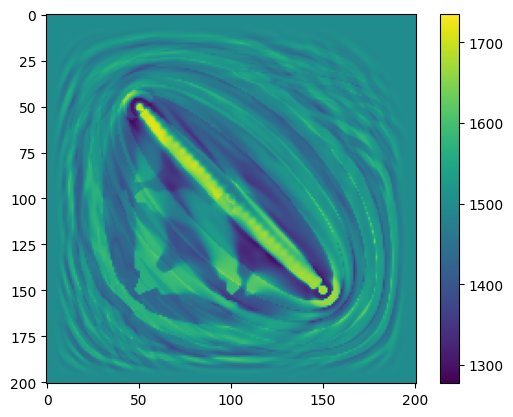

60514.465


In [28]:
from tqdm import tqdm

# Wrap the fwi function with a progress bar

# Create a wrapper to track progress during FWI iterations
def fwi_with_progress(src_indices, pbar=None):
    result = fwi(src_indices)
    if pbar is not None:
        pbar.update(1)
    return result

iin = fwi_with_progress(src_indices, pbar=tqdm(range(10)))
plt.imshow(iin)
plt.colorbar()
plt.show()
# L1 loss
print(jnp.linalg.norm((iin - jnp.fliplr(true_model)), ord=1))